# 01 - Exploración del Dataset Blood Cell Image Dataset


#Verificación de GPU

In [1]:
import torch

print("Versión de PyTorch:", torch.__version__)
print("GPU disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Versión de PyTorch: 2.10.0+cu128
GPU disponible: True
GPU: Tesla T4


# Integración y verificación de archivo .JSON de Kaggle

In [2]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"axelypr","key":"b1aac0b0298913cfaa35f97c4f65fbb4"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle --version

Kaggle CLI 2.0.2


# Descarga del dataset

In [5]:
!mkdir -p data/blood_cells
!kaggle datasets download -d paultimothymooney/blood-cells -p data/blood_cells
!unzip -q data/blood_cells/blood-cells.zip -d data/blood_cells

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/blood-cells
License(s): other
100% 108M/108M [00:00<00:00, 144MB/s]



In [6]:
!find data/blood_cells -maxdepth 5 -type d

data/blood_cells
data/blood_cells/dataset2-master
data/blood_cells/dataset2-master/dataset2-master
data/blood_cells/dataset2-master/dataset2-master/images
data/blood_cells/dataset2-master/dataset2-master/images/TEST
data/blood_cells/dataset2-master/dataset2-master/images/TEST/EOSINOPHIL
data/blood_cells/dataset2-master/dataset2-master/images/TEST/MONOCYTE
data/blood_cells/dataset2-master/dataset2-master/images/TEST/LYMPHOCYTE
data/blood_cells/dataset2-master/dataset2-master/images/TEST/NEUTROPHIL
data/blood_cells/dataset2-master/dataset2-master/images/TRAIN
data/blood_cells/dataset2-master/dataset2-master/images/TRAIN/EOSINOPHIL
data/blood_cells/dataset2-master/dataset2-master/images/TRAIN/MONOCYTE
data/blood_cells/dataset2-master/dataset2-master/images/TRAIN/LYMPHOCYTE
data/blood_cells/dataset2-master/dataset2-master/images/TRAIN/NEUTROPHIL
data/blood_cells/dataset2-master/dataset2-master/images/TEST_SIMPLE
data/blood_cells/dataset2-master/dataset2-master/images/TEST_SIMPLE/EOSINOPHIL

# Análisis Exploratorio del Dataset

En esta sección se revisa la distribución de clases, se visualizan ejemplos por clase y se verifican dimensiones básicas de las imágenes. Este análisis sirve como base para los experimentos posteriores con CNN y Transfer Learning.


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

DATA_DIR = "data/blood_cells/dataset2-master/dataset2-master/images"
TRAIN_DIR = os.path.join(DATA_DIR, "TRAIN")
TEST_DIR = os.path.join(DATA_DIR, "TEST")

print("TRAIN_DIR existe:", os.path.exists(TRAIN_DIR))
print("TEST_DIR existe:", os.path.exists(TEST_DIR))
print("Clases:", sorted(os.listdir(TRAIN_DIR)))


TRAIN_DIR existe: True
TEST_DIR existe: True
Clases: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']


In [7]:
def count_images_by_class(split_dir):
    rows = []
    for class_name in sorted(os.listdir(split_dir)):
        class_path = os.path.join(split_dir, class_name)
        if os.path.isdir(class_path):
            images = [f for f in os.listdir(class_path) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
            rows.append({"Clase": class_name, "Cantidad": len(images)})
    return pd.DataFrame(rows)

train_counts = count_images_by_class(TRAIN_DIR)
test_counts = count_images_by_class(TEST_DIR)

print("Distribución TRAIN")
display(train_counts)

print("Distribución TEST")
display(test_counts)


Distribución TRAIN


,Clase,Cantidad
0,EOSINOPHIL,2497
1,LYMPHOCYTE,2483
2,MONOCYTE,2478
3,NEUTROPHIL,2499


Distribución TEST


,Clase,Cantidad
0,EOSINOPHIL,623
1,LYMPHOCYTE,620
2,MONOCYTE,620
3,NEUTROPHIL,624


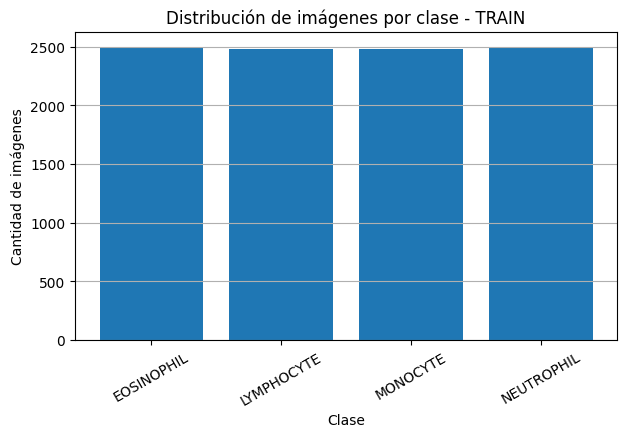

In [8]:
plt.figure(figsize=(7, 4))
plt.bar(train_counts["Clase"], train_counts["Cantidad"])
plt.xlabel("Clase")
plt.ylabel("Cantidad de imágenes")
plt.title("Distribución de imágenes por clase - TRAIN")
plt.xticks(rotation=30)
plt.grid(axis="y")
plt.show()


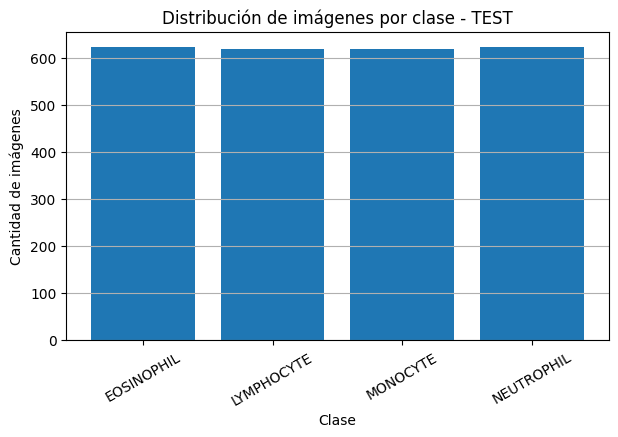

In [9]:
plt.figure(figsize=(7, 4))
plt.bar(test_counts["Clase"], test_counts["Cantidad"])
plt.xlabel("Clase")
plt.ylabel("Cantidad de imágenes")
plt.title("Distribución de imágenes por clase - TEST")
plt.xticks(rotation=30)
plt.grid(axis="y")
plt.show()


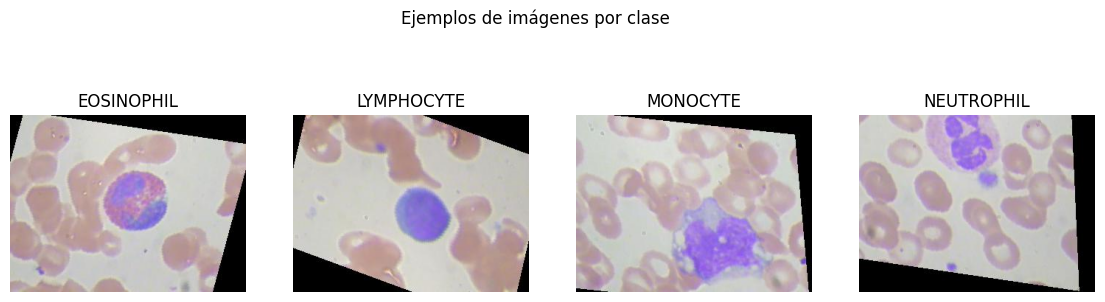

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for idx, class_name in enumerate(sorted(os.listdir(TRAIN_DIR))):
    class_path = os.path.join(TRAIN_DIR, class_name)
    img_name = [f for f in os.listdir(class_path) if f.lower().endswith((".jpg", ".jpeg", ".png"))][0]
    img_path = os.path.join(class_path, img_name)
    img = Image.open(img_path)

    axes[idx].imshow(img)
    axes[idx].set_title(class_name)
    axes[idx].axis("off")

plt.suptitle("Ejemplos de imágenes por clase")
plt.show()


In [11]:
image_sizes = []

for class_name in sorted(os.listdir(TRAIN_DIR)):
    class_path = os.path.join(TRAIN_DIR, class_name)
    sample_images = [f for f in os.listdir(class_path) if f.lower().endswith((".jpg", ".jpeg", ".png"))][:20]
    for img_name in sample_images:
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path)
        image_sizes.append({
            "Clase": class_name,
            "Width": img.size[0],
            "Height": img.size[1],
            "Mode": img.mode
        })

sizes_df = pd.DataFrame(image_sizes)
display(sizes_df.head())
print("Tamaños únicos encontrados en la muestra:")
display(sizes_df.drop_duplicates())


,Clase,Width,Height,Mode
0,EOSINOPHIL,320,240,RGB
1,EOSINOPHIL,320,240,RGB
2,EOSINOPHIL,320,240,RGB
3,EOSINOPHIL,320,240,RGB
4,EOSINOPHIL,320,240,RGB


Tamaños únicos encontrados en la muestra:


,Clase,Width,Height,Mode
0,EOSINOPHIL,320,240,RGB
20,LYMPHOCYTE,320,240,RGB
40,MONOCYTE,320,240,RGB
60,NEUTROPHIL,320,240,RGB


## Conclusión del EDA

El dataset se encuentra organizado en carpetas `TRAIN` y `TEST`, con cuatro clases: `EOSINOPHIL`, `LYMPHOCYTE`, `MONOCYTE` y `NEUTROPHIL`. Las imágenes son RGB y serán redimensionadas según el experimento: `64x64` para las CNN entrenadas desde cero y `224x224` para ResNet-18 preentrenada.
